In [ ]:
# Importar as bibliotecas

import datetime
import json
import os
from pathlib import Path
import pandas
import seaborn as sns
import sys
import matplotlib.pyplot as plt

In [ ]:
# Resolver os 'imports' do projeto 

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from utils.classes.pandas_dataframe import PandasDataframe as pd_dataframe

In [ ]:
# Trazer as opções de configuração do JSON

json_file = os.path.abspath('../../options.json')

with open(json_file, 'r', encoding='utf-8') as j_file:
    json_data = json.load(j_file)

In [ ]:
# Declaração dos caminhos

dir_archive = os.path.abspath('../../data')

dir_cvm = os.path.join(dir_archive, 'cvm')
dir_cdi = os.path.join(dir_archive, 'cdi')

dir_cvm_processed = os.path.join(dir_cvm, json_data['DIR']['CVM']['DATA_NAME'])

In [ ]:
# Manejo da data dos investimentos

START_DATE = json_data['CONFIG']['START_DATE']
END_DATE = json_data.get("CONFIG", False).get("END_DATE", False) or str(datetime.date.today())

In [ ]:
# Gráfico de evolução do preço das cotas

cvm_files = os.listdir(dir_cvm_processed)
all_data = []

for investment_file in cvm_files:
    investment_path = os.path.join(dir_cvm_processed, investment_file)

    investment = pd_dataframe(investment_path, None)

    investment.csv_to_df()
    investment.query_date(START_DATE, END_DATE, 'DT_COMPTC')
    investment.order_columns(['DT_COMPTC', 'VL_QUOTA', 'NOME_FUNDOS', 'CNPJ_FUNDO_CLASSE'])

    all_data.append(investment.df)

investment = pd_dataframe(None, None, list=all_data)
investment.list_to_df()

investment.df['DT_COMPTC'] = pandas.to_datetime(investment.df['DT_COMPTC'])
investment.sort_elements_list(['DT_COMPTC'])

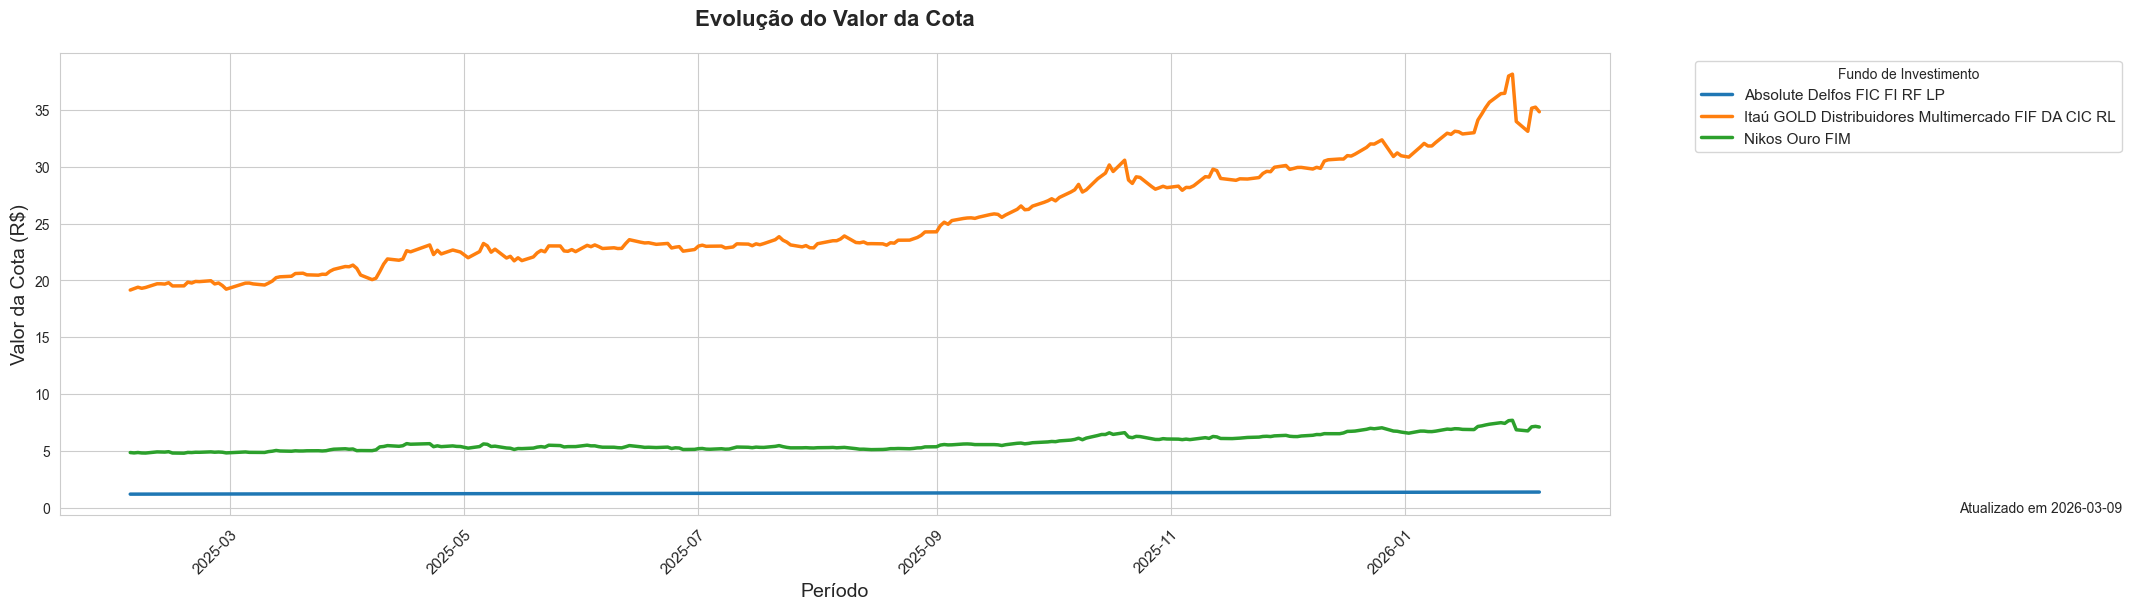

In [ ]:
# Gráfico de evolução do preço das cotas

sns.set_style("whitegrid")
plt.figure(figsize=(20, 6))

plot = sns.lineplot(
    data=investment.df, 
    x='DT_COMPTC', 
    y='VL_QUOTA', 
    hue='NOME_FUNDOS', 
    linewidth=2.5
)

plt.title("Evolução do Valor da Cota", fontsize=16, fontweight='bold', pad=20)
plt.text(
    1.225, 0.0,
    "Atualizado em " + str(datetime.datetime.today().date()), 
    transform=plt.gca().transAxes, 
    fontsize=10, 
    va='bottom', ha='left'
)

plt.xlabel("Período", fontsize=14)
plt.ylabel("Valor da Cota (R$)", fontsize=14)
plt.xticks(
    rotation=45, 
    fontsize=11,
    ha='right',
    rotation_mode= 'anchor'
)
plt.legend(
    title='Métricas', 
    bbox_to_anchor=(1.05, 1), 
    fontsize=11
)

plt.gca().tick_params(axis='x', pad=5)
plt.show()
